In [1]:
import ChessLens

from Dataset.DataSetLoaders import ChessDataset

import numpy as np
from matplotlib import pyplot as plt

from tqdm import tqdm

In [2]:
ds = ChessDataset.ChessDataset(
    root_dirs="/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4",
    config={
        "img_size": (640,640)
    },
    force_build_pkl=True
)

'/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_1.jpg'

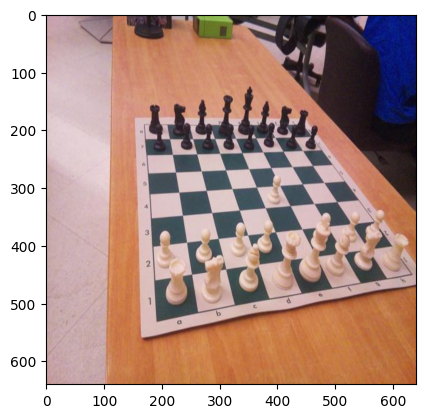

In [3]:
img, y = ds[1]

plt.imshow(img.permute(1,2,0));
y["image_path"]

/mnt/D/University/Thesis/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


'/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_1.jpg'

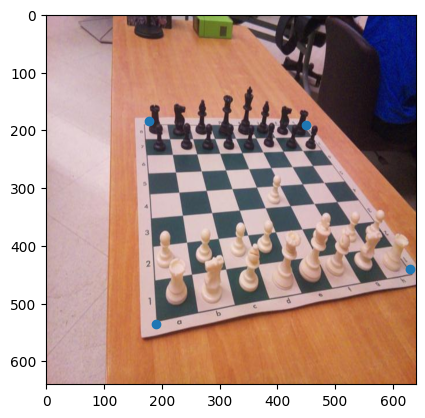

In [4]:
img = ChessLens.ChessLensImage(img)
img.detect_board()

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
img.board_detection.reshape(-1).to(int).tolist()

y["image_path"]

In [5]:
res = []

for i in tqdm(range(len(ds))):
    try:
        img, y = ds[i]

        img = ChessLens.ChessLensImage(img)
        img.detect_board()

        tmp = img.board_detection
        tmp[:,1] *= 480/640
        res.append(f"{y["image_path"]}:{",".join(map(lambda x: str(x), tmp.reshape(-1).to(int).tolist()))}")
    except:
        res.append(f"{y["image_path"]}:{",".join(["0"]*8)}")

        print(f"Image Failed at {y["image_path"]}")

res

 71%|███████   | 59/83 [00:13<00:04,  5.48it/s]

Image Failed at /mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_58.jpg


100%|██████████| 83/83 [00:18<00:00,  4.55it/s]

Image Failed at /mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_82.jpg


['/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_0.jpg:219,117,518,147,609,375,127,312',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_1.jpg:177,138,449,142,630,330,190,401',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_2.jpg:233,60,537,110,548,369,81,262',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_3.jpg:164,135,404,126,590,258,261,331',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_4.jpg:234,78,491,102,572,266,169,219',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_5.jpg:253,72,498,72,625,264,241,256',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_6.jpg:244,102,521,141,510,405,113,319',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_7.jpg:144,141,413,93,566,278,227,393',
 '/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset4/Images/image_8.jpg:207,78,462,92,548,207,149,195',
 '/mnt/D/University/Thesis_Dataset/P

In [6]:
with open("tmp.txt", "w") as f:
    f.write("\n".join(res))

# Testing

In [31]:
i = 50

93 /mnt/D/University/Thesis_Dataset/Phone_Angles_Dataset/game2/image_23.jpg
tensor([[191.0000,  93.3333],
        [469.0000, 104.0000],
        [603.0000, 508.0000],
        [105.0000, 494.6667]])


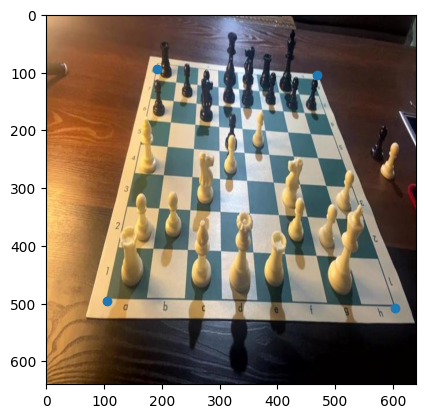

In [75]:
img, y = ds[i]

plt.imshow(img.permute(1,2,0));
plt.scatter(y["corners"][:,0], y["corners"][:,1]);

print(i, y["image_path"])
print(y["corners"])
i += 1